In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from dataset.dataloader import get_dataloaders



In [ ]:
# ============================================================
# 2. CONFIGURATION — 4 SETTINGS × 2 ARCHITECTURES
# ============================================================

# We have TWO architectures in every training setting:
#   - MLP
#   - CNN
#
# And FOUR training/settings:
#   1. Simple + Adam
#   2. Complex + Adam
#   3. Simple + SGD
#   4. Complex + SGD
#


MODEL_PATHS = {
    "Simple + Adam": {
        "MLP": r"C:\Users\palal oza\Desktop\Plaksha\capstone_python\results\results_simple_adam30_lr_0.001\models\mlp_model.pth",
        "CNN": r"C:\Users\palal oza\Desktop\Plaksha\capstone_python\results\results_simple_adam30_lr_0.001\models\cnn_model.pth",
    },

    "Complex + Adam": {
        "MLP": r"results\results_ep_ds6000_og_arc_optim_adam30_lr_0.001\models\mlp_model.pth",
        "CNN": r"results\results_ep_ds6000_og_arc_optim_adam30_lr_0.001\models\cnn_model.pth",
    },

    "Simple + SGD": {
        "MLP": r"results\results_simple_sgd30_lr_0.001\models\mlp_model.pth",
        "CNN": r"results\results_simple_sgd30_lr_0.001\models\cnn_model.pth",
    },

    "Complex + SGD": {
        "MLP": r"results\results_sgd_ogarc30_lr_0.001\models\mlp_model.pth",
        "CNN": r"results\results_sgd_ogarc30_lr_0.001\models\cnn_model.pth",
    },
}

BATCH_SIZE = 64
SEED = 42

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("\nConfigured experiments:")
for setting, paths in MODEL_PATHS.items():
    print(f"\n{setting}")
    for architecture, model_path in paths.items():
        print(f"  {architecture}: {model_path}")


Device: cpu

Configured experiments:

Simple + Adam
  MLP: C:\Users\palal oza\Desktop\Plaksha\capstone_python\results\results_simple_adam30_lr_0.001\models\mlp_model.pth
  CNN: C:\Users\palal oza\Desktop\Plaksha\capstone_python\results\results_simple_adam30_lr_0.001\models\cnn_model.pth

Complex + Adam
  MLP: results\results_ep_ds6000_og_arc_optim_adam30_lr_0.001\models\mlp_model.pth
  CNN: results\results_ep_ds6000_og_arc_optim_adam30_lr_0.001\models\cnn_model.pth

Simple + SGD
  MLP: results\results_simple_sgd30_lr_0.001\models\mlp_model.pth
  CNN: results\results_simple_sgd30_lr_0.001\models\cnn_model.pth

Complex + SGD
  MLP: results\results_sgd_ogarc30_lr_0.001\models\mlp_model.pth
  CNN: results\results_sgd_ogarc30_lr_0.001\models\cnn_model.pth


In [3]:
# ============================================================
# 3. ARCHITECTURE CONSTRUCTORS
# ============================================================

from architecture.mlparc import mlp_arc
from architecture.convnn import cnn_arc
from architecture.sim_conv import cnn_arc_sim
from architecture.mlp_simple import mlp_arc_sim

MODEL_BUILDERS = {
    "Simple + Adam": {
        "MLP": mlp_arc_sim,
        "CNN": cnn_arc_sim,
    },
    "Complex + Adam": {
        "MLP": mlp_arc,
        "CNN": cnn_arc,
    },
    "Simple + SGD": {
        "MLP": mlp_arc_sim,
        "CNN": cnn_arc_sim,
    },
    "Complex + SGD": {
        "MLP": mlp_arc,
        "CNN": cnn_arc,
    },
}

print("Architecture builders configured.")


Architecture builders configured.


In [4]:
# ============================================================
# 4. LOAD TEST DATA
# ============================================================

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE,
    seed=SEED
)

print("Test data loaded.")
print("Number of test samples:", len(test_loader.dataset))


Test data loaded.
Number of test samples: 600


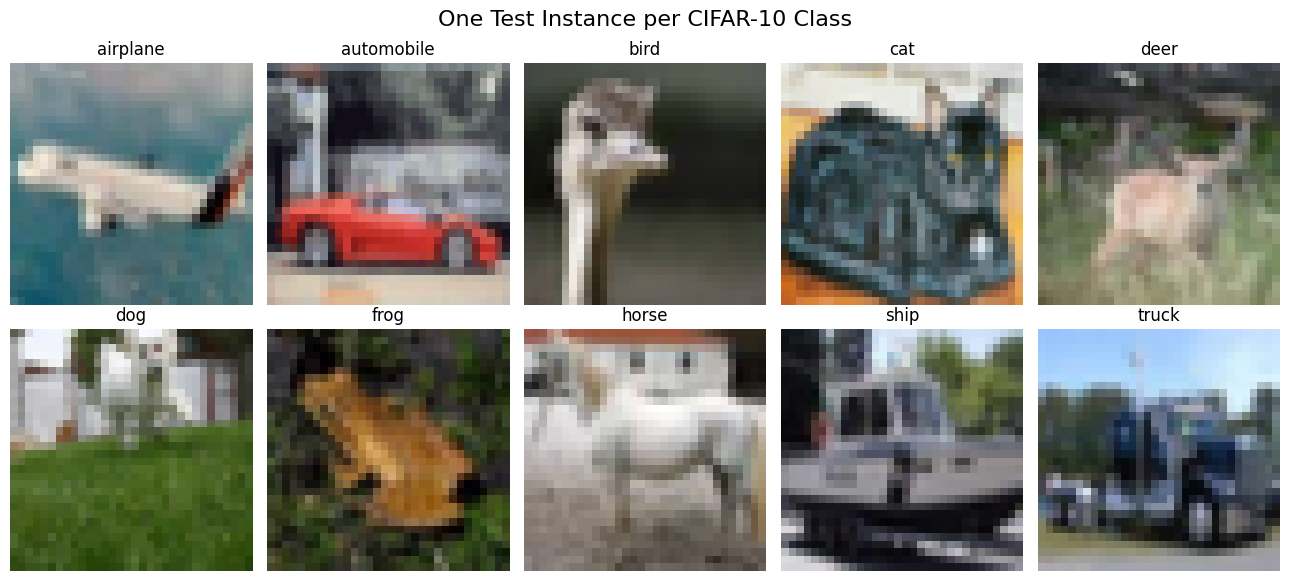

In [ ]:
# ============================================================
# 5. DATA VISUALIZATION
# ============================================================

def unnormalize_cifar10(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465], device=img.device).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616], device=img.device).view(3, 1, 1)
    return img * std + mean

examples = {}
for images, labels in test_loader:
    for image, label in zip(images, labels):
        label_int = int(label)
        if label_int not in examples:
            examples[label_int] = image.cpu()
        if len(examples) == len(CLASS_NAMES):
            break
    if len(examples) == len(CLASS_NAMES):
        break

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.ravel()

for class_idx in range(len(CLASS_NAMES)):
    image = examples[class_idx]

    image_display = unnormalize_cifar10(image).clamp(0, 1)
    image_display = image_display.permute(1, 2, 0).numpy()

    axes[class_idx].imshow(image_display)
    axes[class_idx].set_title(CLASS_NAMES[class_idx])
    axes[class_idx].axis("off")

plt.suptitle("One Test Instance per CIFAR-10 Class", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 6. MODEL LOADING — 8 MODELS
# ============================================================

def load_model(model_name, architecture, model_path):
    if model_name not in MODEL_BUILDERS:
        raise KeyError(f"Unknown setting: {model_name}")

    if architecture not in MODEL_BUILDERS[model_name]:
        raise KeyError(
            f"No {architecture} constructor configured for {model_name}"
        )

    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"Checkpoint not found for {model_name} / {architecture}: "
            f"{model_path}"
        )

    model = MODEL_BUILDERS[model_name][architecture]()

    checkpoint = torch.load(model_path, map_location=DEVICE)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    state_dict = {
        k.replace("module.", "", 1) if k.startswith("module.") else k: v
        for k, v in state_dict.items()
    }

    model.load_state_dict(state_dict)
    model = model.to(DEVICE)
    model.eval()

    return model


models = {}

for setting, architecture_paths in MODEL_PATHS.items():
    models[setting] = {}

    for architecture, model_path in architecture_paths.items():
        print(f"Loading {setting} — {architecture}...")
        models[setting][architecture] = load_model(
            setting,
            architecture,
            model_path
        )
        print("  Loaded successfully.")

print("\nAll 8 models loaded.")


Loading Simple + Adam — MLP...
  Loaded successfully.
Loading Simple + Adam — CNN...
  Loaded successfully.
Loading Complex + Adam — MLP...
  Loaded successfully.
Loading Complex + Adam — CNN...
  Loaded successfully.
Loading Simple + SGD — MLP...
  Loaded successfully.
Loading Simple + SGD — CNN...
  Loaded successfully.
Loading Complex + SGD — MLP...
  Loaded successfully.
Loading Complex + SGD — CNN...
  Loaded successfully.

All 8 models loaded.


In [ ]:
# ============================================================
# 7. EVALUATION — 8 MODELS USING metrics2.py
# ============================================================

# metrics2.py calculates:
#   - Test Loss
#   - Accuracy
#   - Macro Precision
#   - Macro Recall
#   - Macro F1
#   - Confusion Matrix
#   - Per-class Accuracy
#   - Per-class Precision
#   - Per-class Recall
#   - Per-class F1
# ============================================================

from metrics2 import evaluate_all_models


# Evaluate all 8 existing checkpoints
metrics2_results = evaluate_all_models(
    model_paths=MODEL_PATHS,
    model_builders=MODEL_BUILDERS,
    test_loader=test_loader,
    device=DEVICE
)

results = {}

for setting in metrics2_results:

    results[setting] = {}

    for architecture in metrics2_results[setting]:

        m = metrics2_results[setting][architecture]

        results[setting][architecture] = {
            "loss": m["loss"],
            "accuracy": m["accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "confusion_matrix": m["confusion_matrix"],
            "per_class_accuracy": np.array([
                m["class_accuracy"][class_name]
                for class_name in CLASS_NAMES
            ]),

            "per_class_precision": np.array([
                m["class_precision"][class_name]
                for class_name in CLASS_NAMES
            ]),

            "per_class_recall": np.array([
                m["class_recall"][class_name]
                for class_name in CLASS_NAMES
            ]),

            "per_class_f1": np.array([
                m["class_f1"][class_name]
                for class_name in CLASS_NAMES
            ])
        }


print("\n" + "=" * 70)
print("ALL 8 MODELS EVALUATED")
print("=" * 70)
print("No training was performed.")





######################################################################
Simple + Adam
######################################################################


------------------------------------------------------------
MLP
------------------------------------------------------------

LOADING MODEL
Model: C:\Users\palal oza\Desktop\Plaksha\capstone_python\results\results_simple_adam30_lr_0.001\models\mlp_model.pth

RESULTS
------------------------------------------------------------
Test Loss : 2.9608
Accuracy  : 38.67%
Precision : 38.65%
Recall    : 38.67%
F1 Score  : 38.41%


------------------------------------------------------------
CNN
------------------------------------------------------------

LOADING MODEL
Model: C:\Users\palal oza\Desktop\Plaksha\capstone_python\results\results_simple_adam30_lr_0.001\models\cnn_model.pth

RESULTS
------------------------------------------------------------
Test Loss : 3.1685
Accuracy  : 53.00%
Precision : 53.03%
Recall    : 53.00%
F1 Score

In [8]:
# ============================================================
# 8. OVERALL RESULTS TABLE
# ============================================================

summary_rows = []

for setting, architecture_results in results.items():

    for architecture, result in architecture_results.items():

        summary_rows.append({
            "Setting": setting,
            "Architecture": architecture,
            "Test Loss": result["loss"],
            "Accuracy (%)": result["accuracy"] * 100,
            "Precision (%)": result["precision"] * 100,
            "Recall (%)": result["recall"] * 100,
            "F1 Score (%)": result["f1"] * 100,
        })


summary_df = pd.DataFrame(summary_rows)


print("\nOverall comparison of all 8 trained models:")

display(
    summary_df.sort_values(
        "Accuracy (%)",
        ascending=False
    ).reset_index(drop=True).style.format({
        "Test Loss": "{:.4f}",
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1 Score (%)": "{:.2f}",
    })
)



Overall comparison of all 8 trained models:


,Setting,Architecture,Test Loss,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Complex + Adam,CNN,2.9986,56.67,56.62,56.67,56.42
1,Simple + Adam,CNN,3.1685,53.00,53.03,53.00,52.89
2,Complex + Adam,MLP,4.4116,41.83,41.77,41.83,41.06
3,Simple + SGD,MLP,1.7688,39.83,39.51,39.83,38.99
4,Simple + Adam,MLP,2.9608,38.67,38.65,38.67,38.41
5,Complex + SGD,MLP,1.9247,34.00,36.21,34.00,31.68
6,Complex + SGD,CNN,1.9399,33.50,32.27,33.50,31.02
7,Simple + SGD,CNN,2.0356,28.17,24.09,28.17,23.58


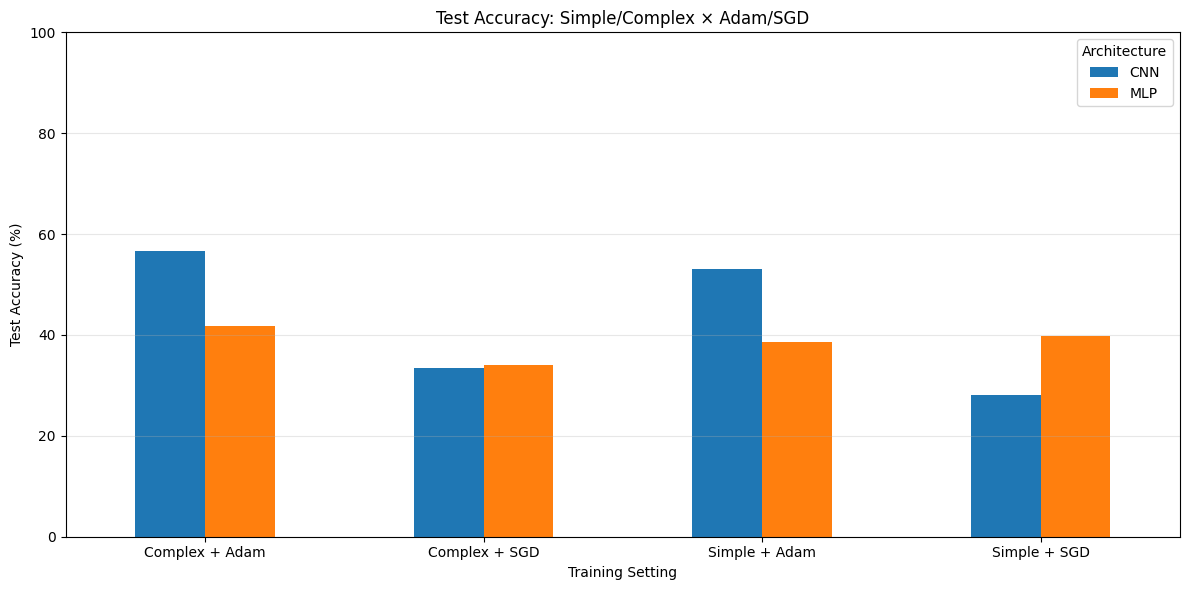

In [9]:
# ============================================================
# 9. ACCURACY COMPARISON — FOUR SETTINGS
# ============================================================

pivot_accuracy = summary_df.pivot(
    index="Setting",
    columns="Architecture",
    values="Accuracy (%)"
)

ax = pivot_accuracy.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Test Accuracy: Simple/Complex × Adam/SGD")
ax.set_xlabel("Training Setting")
ax.set_ylabel("Test Accuracy (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.legend(title="Architecture")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


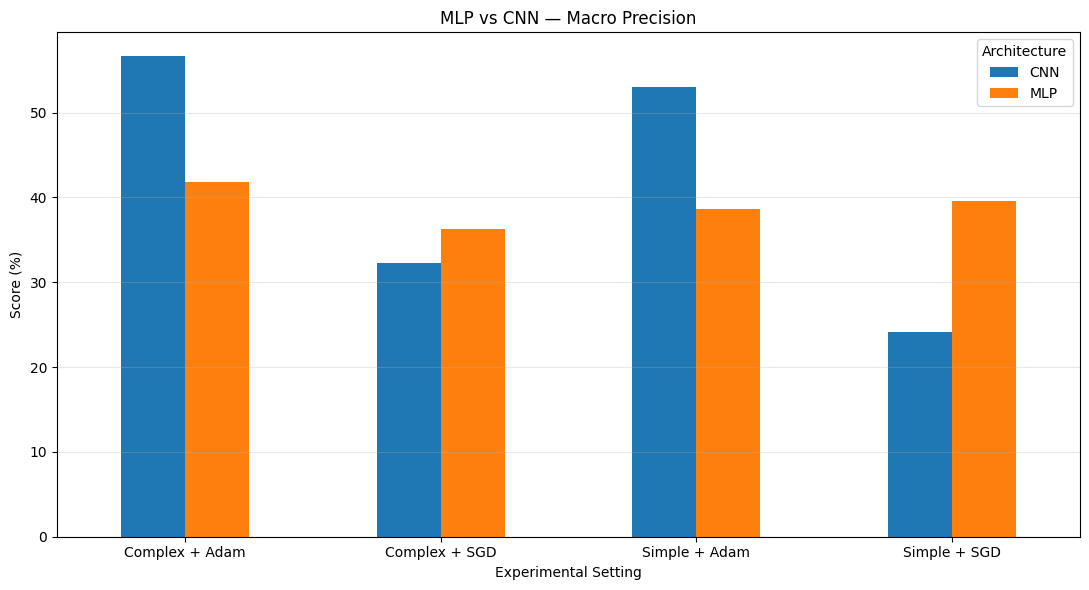

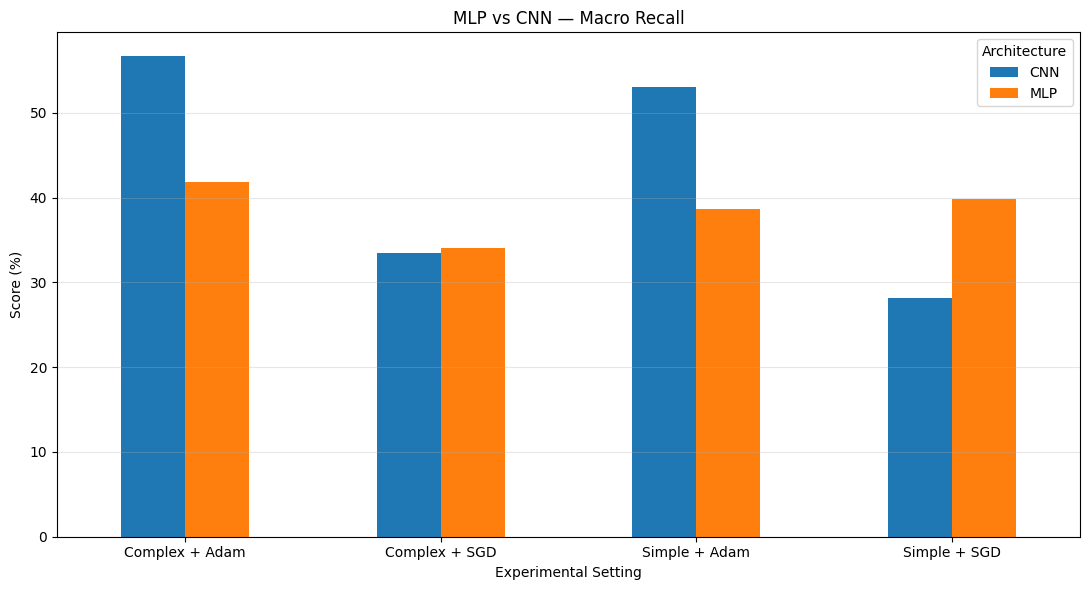

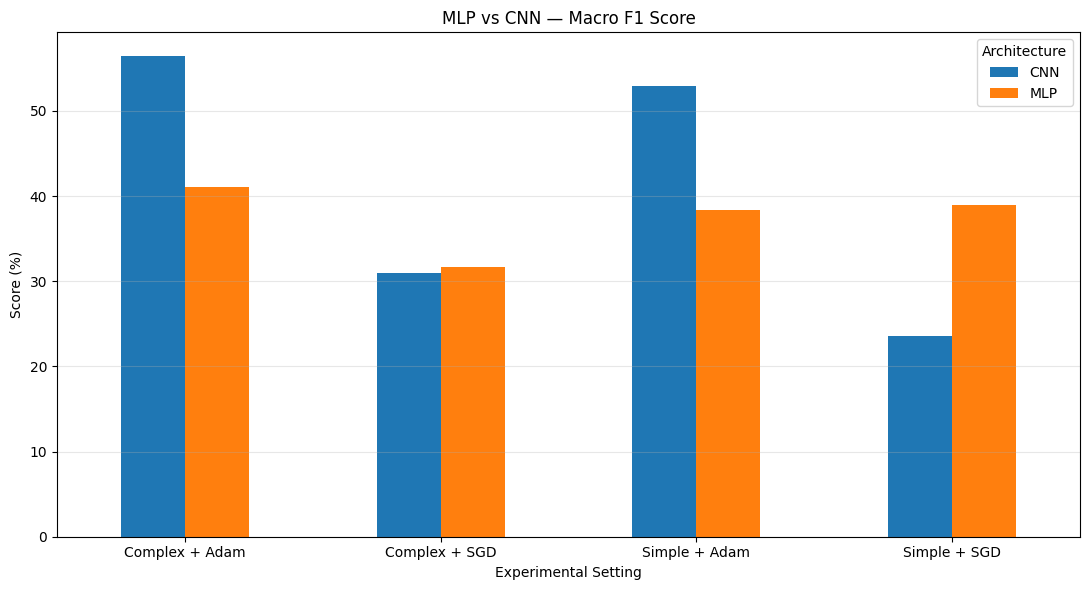

In [10]:
# ============================================================
# 9B. PRECISION / RECALL / F1 COMPARISON
# ============================================================

metrics_to_plot = [
    ("Precision (%)", "Macro Precision"),
    ("Recall (%)", "Macro Recall"),
    ("F1 Score (%)", "Macro F1 Score"),
]

for column, title in metrics_to_plot:

    pivot = summary_df.pivot(
        index="Setting",
        columns="Architecture",
        values=column
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.set_title(f"MLP vs CNN — {title}")
    ax.set_xlabel("Experimental Setting")
    ax.set_ylabel("Score (%)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


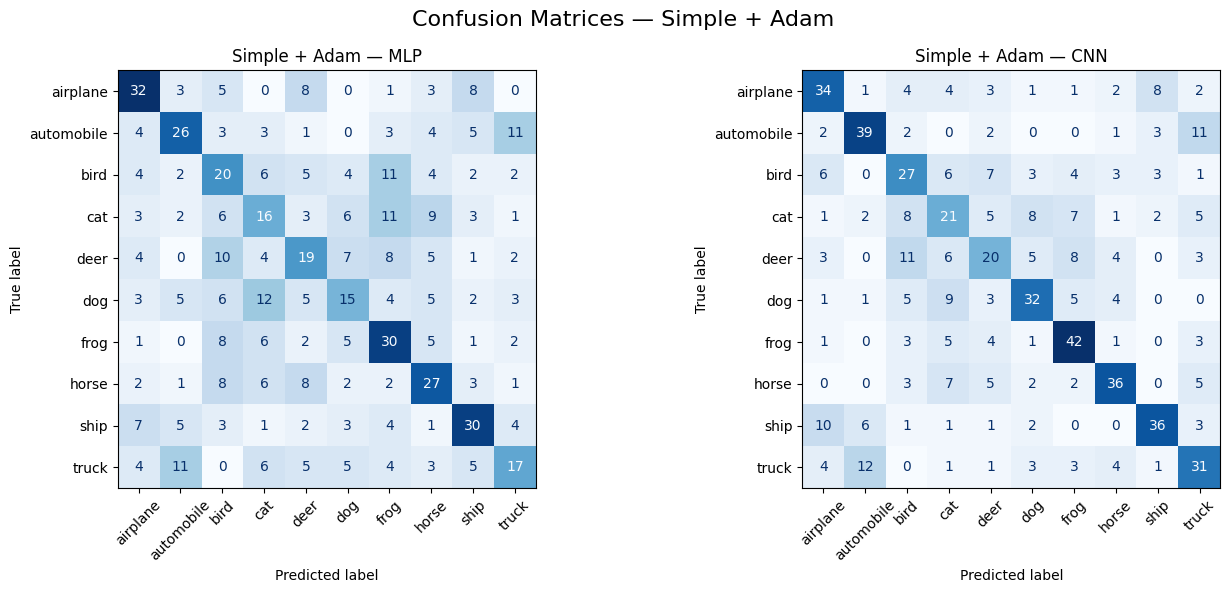

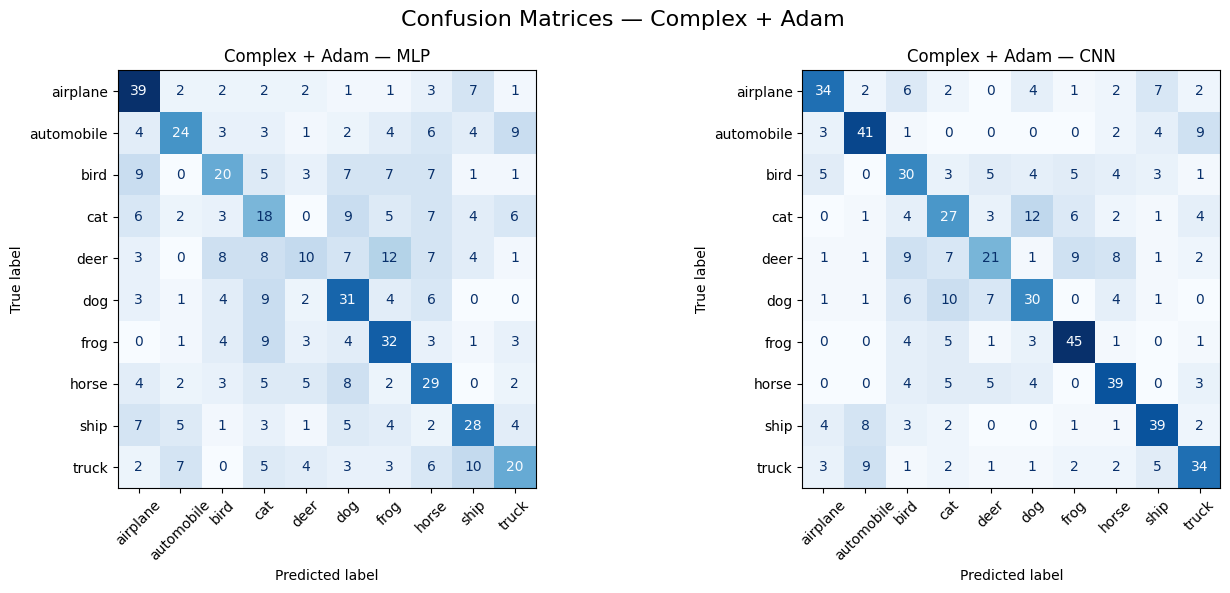

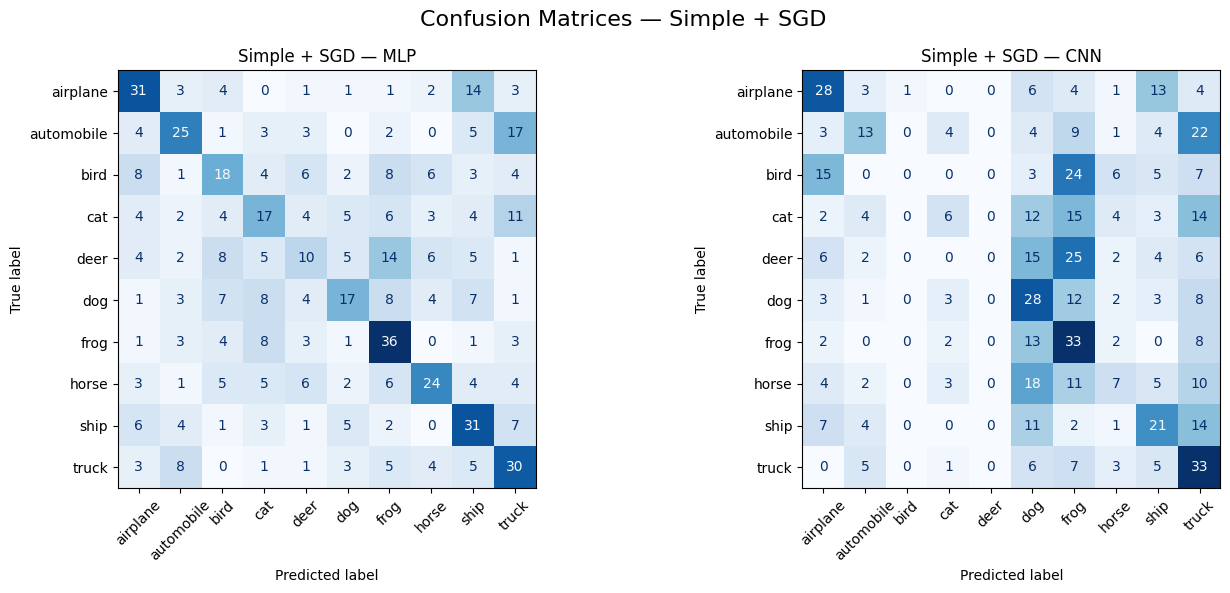

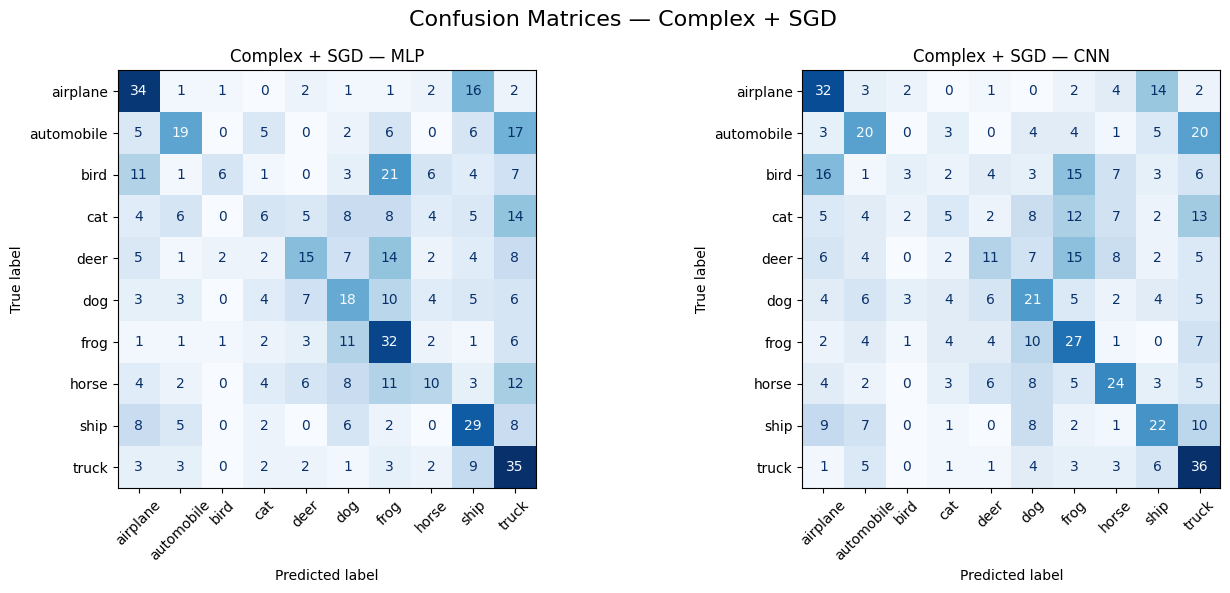

In [11]:
# ============================================================
# 10. CONFUSION MATRICES — ALL 8 MODELS
# ============================================================

for setting in MODEL_PATHS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, architecture in zip(axes, ["MLP", "CNN"]):
        cm = results[setting][architecture]["confusion_matrix"]

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        )

        disp.plot(
            ax=ax,
            cmap="Blues",
            xticks_rotation=45,
            values_format="d",
            colorbar=False
        )

        ax.set_title(f"{setting} — {architecture}")

    fig.suptitle(f"Confusion Matrices — {setting}", fontsize=16)
    plt.tight_layout()
    plt.show()



MLP — per-class accuracy


,Simple + Adam,Complex + Adam,Simple + SGD,Complex + SGD
airplane,53.33,65.00,51.67,56.67
automobile,43.33,40.00,41.67,31.67
bird,33.33,33.33,30.00,10.00
cat,26.67,30.00,28.33,10.00
deer,31.67,16.67,16.67,25.00
dog,25.00,51.67,28.33,30.00
frog,50.00,53.33,60.00,53.33
horse,45.00,48.33,40.00,16.67
ship,50.00,46.67,51.67,48.33
truck,28.33,33.33,50.00,58.33


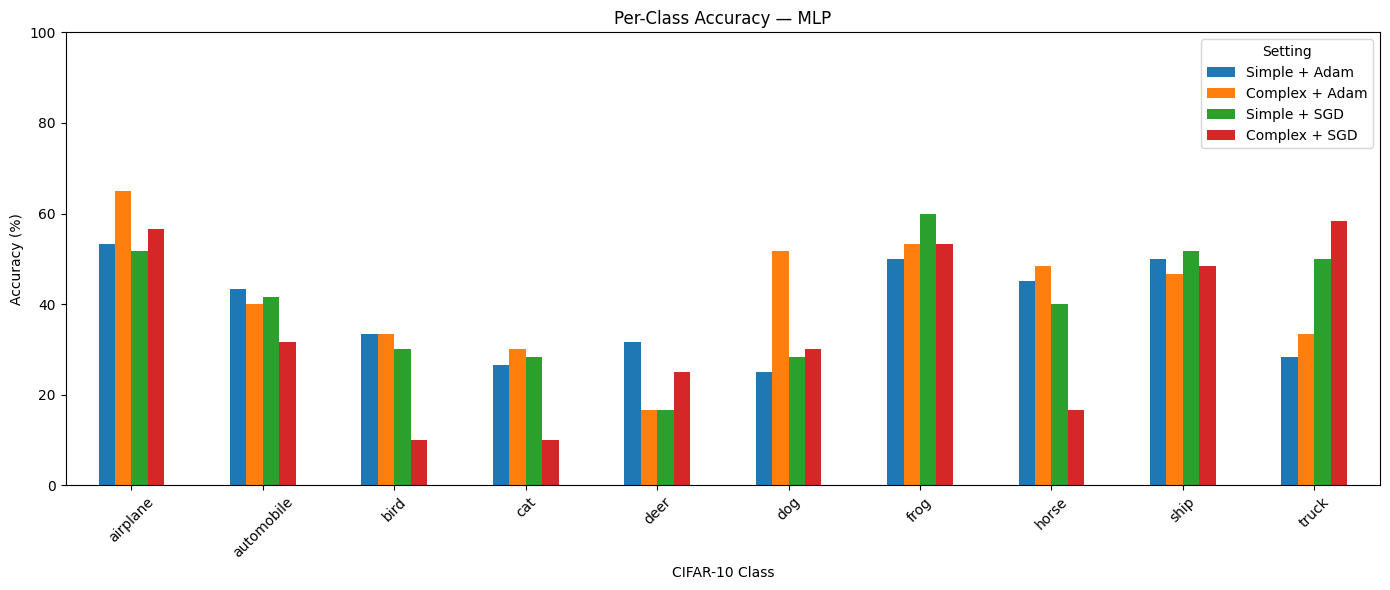


CNN — per-class accuracy


,Simple + Adam,Complex + Adam,Simple + SGD,Complex + SGD
airplane,56.67,56.67,46.67,53.33
automobile,65.00,68.33,21.67,33.33
bird,45.00,50.00,0.00,5.00
cat,35.00,45.00,10.00,8.33
deer,33.33,35.00,0.00,18.33
dog,53.33,50.00,46.67,35.00
frog,70.00,75.00,55.00,45.00
horse,60.00,65.00,11.67,40.00
ship,60.00,65.00,35.00,36.67
truck,51.67,56.67,55.00,60.00


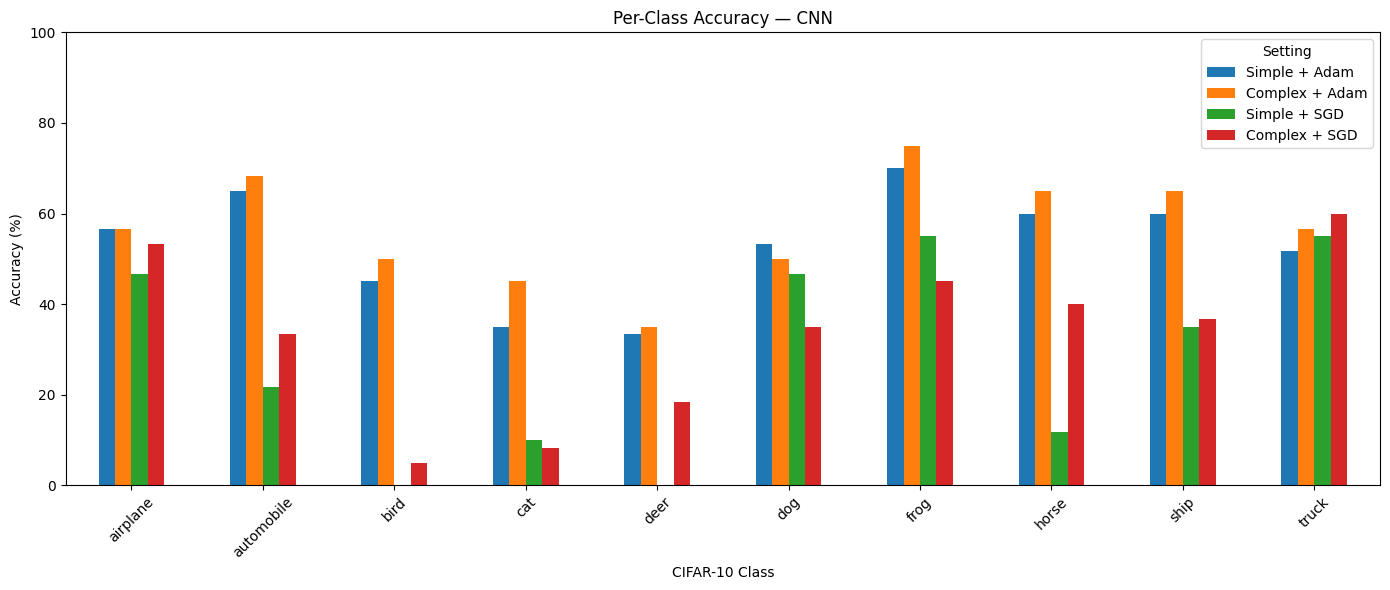

In [12]:
# ============================================================
# 11. PER-CLASS ACCURACY — SETTINGS × ARCHITECTURES
# ============================================================

for architecture in ["MLP", "CNN"]:
    per_class_df = pd.DataFrame({
        setting: results[setting][architecture]["per_class_accuracy"] * 100
        for setting in MODEL_PATHS
    }, index=CLASS_NAMES)

    print(f"\n{architecture} — per-class accuracy")
    display(per_class_df.round(2))

    ax = per_class_df.plot(
        kind="bar",
        figsize=(14, 6)
    )

    ax.set_title(f"Per-Class Accuracy — {architecture}")
    ax.set_xlabel("CIFAR-10 Class")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)

    plt.xticks(rotation=45)
    plt.legend(title="Setting")
    plt.tight_layout()
    plt.show()


## 12. Example predictions

The following visualization uses the same test images and shows what each architecture predicts. Correct predictions are marked in the title; incorrect predictions show the predicted class alongside the true class.


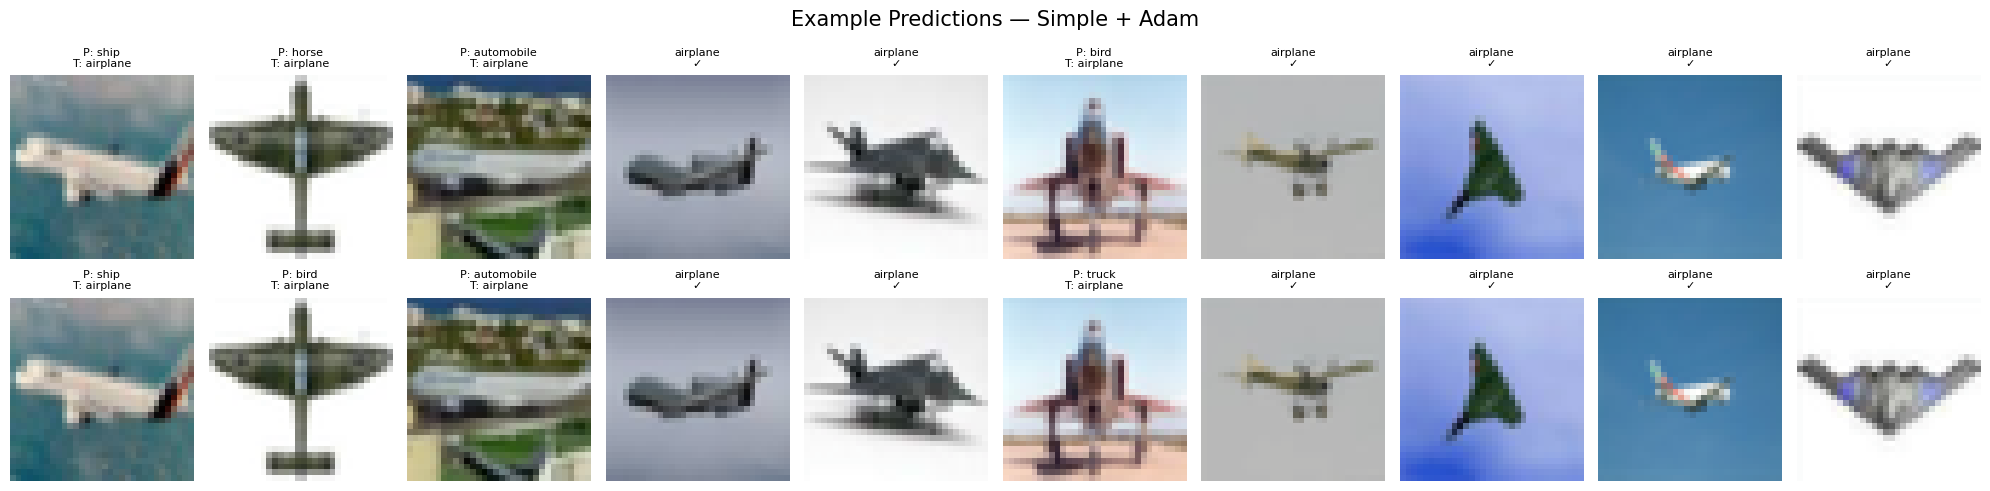

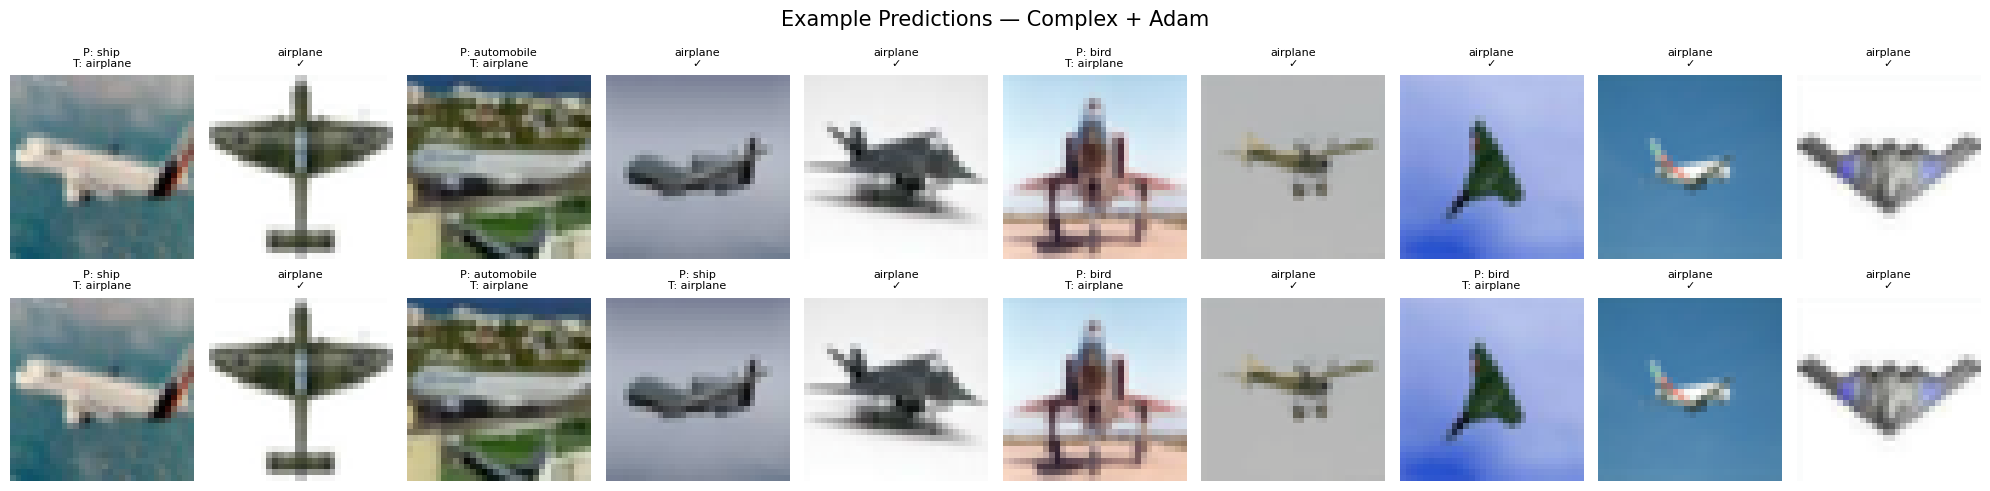

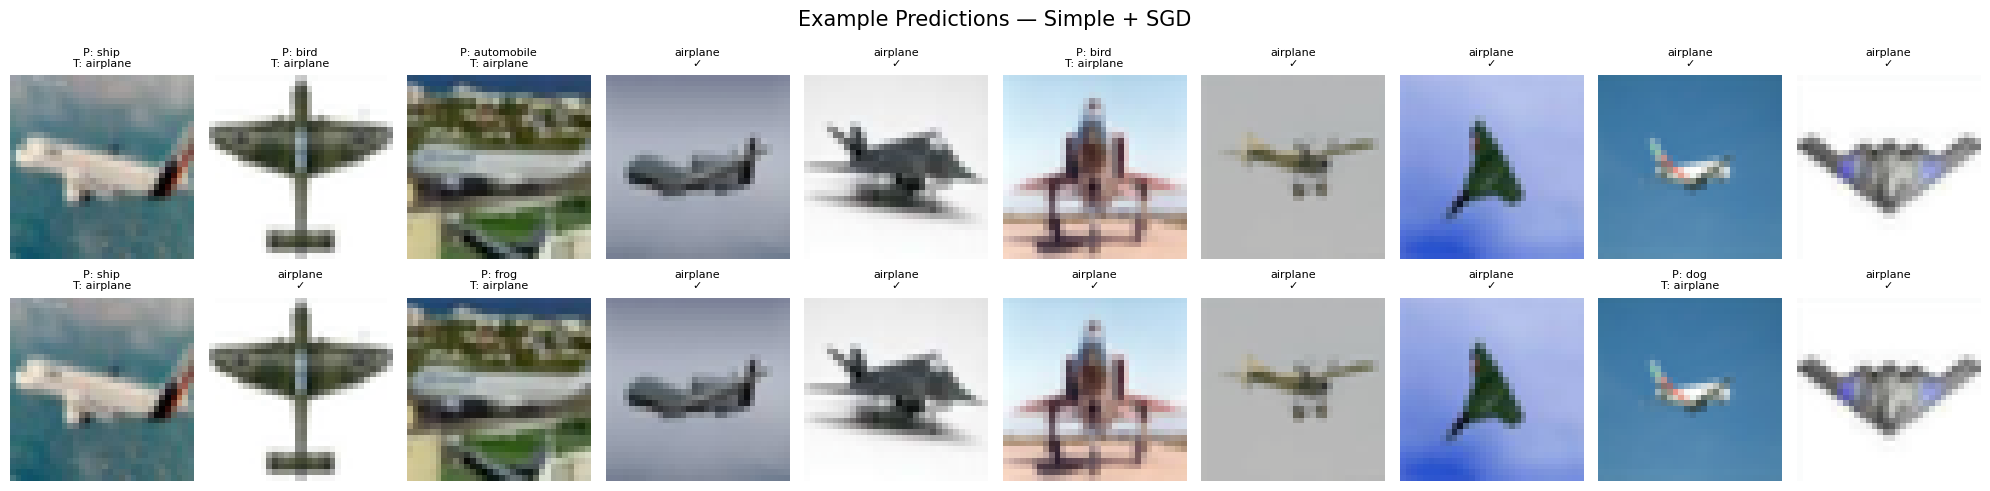

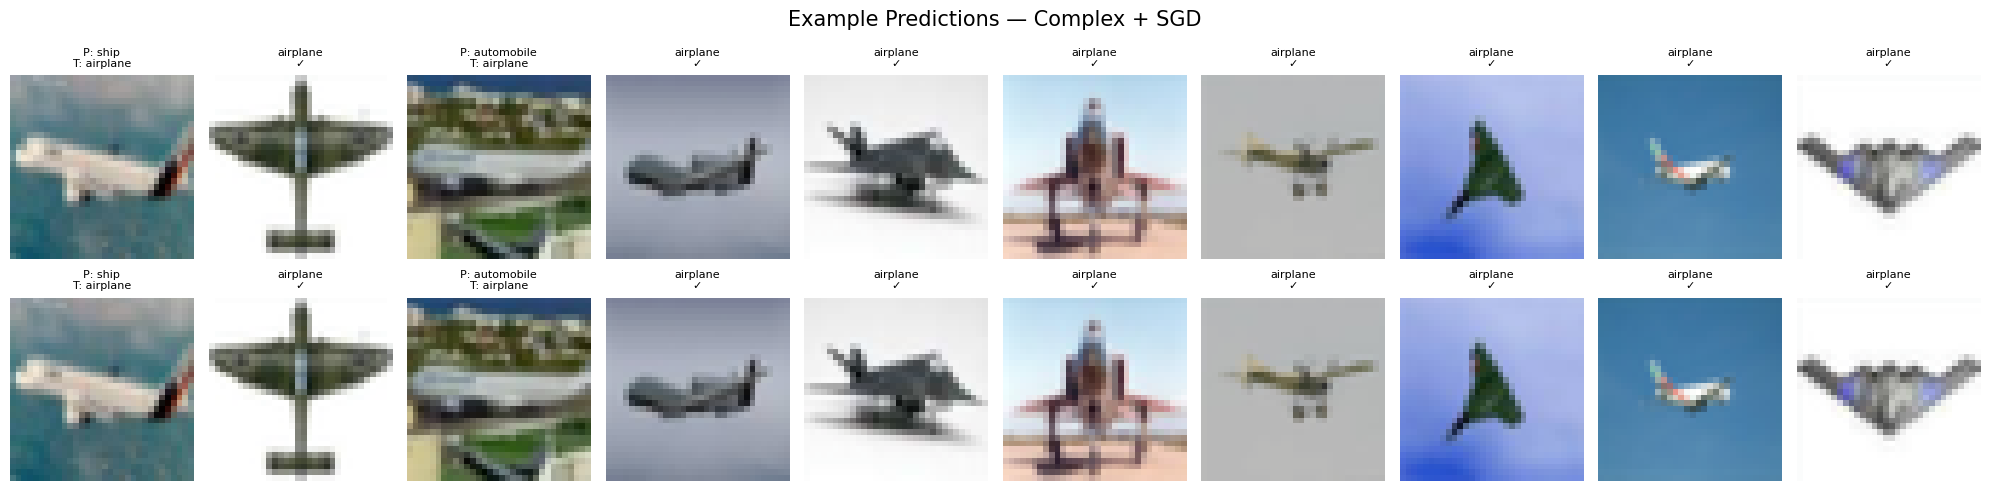

In [13]:
# ============================================================
# 12. EXAMPLE PREDICTIONS — ALL 8 MODELS
# ============================================================

images, labels = next(iter(test_loader))

num_examples = min(10, len(images))
images_small = images[:num_examples]
labels_small = labels[:num_examples]

for setting, architecture_models in models.items():

    fig, axes = plt.subplots(
        2,
        num_examples,
        figsize=(2.0 * num_examples, 5.2)
    )

    for row_idx, architecture in enumerate(["MLP", "CNN"]):
        model = architecture_models[architecture]
        model.eval()

        with torch.no_grad():
            outputs = model(images_small.to(DEVICE))
            predictions = outputs.argmax(dim=1).cpu()

        for col_idx in range(num_examples):
            image = unnormalize_cifar10(
                images_small[col_idx].cpu()
            ).clamp(0, 1)

            image = image.permute(1, 2, 0).numpy()

            true_class = CLASS_NAMES[int(labels_small[col_idx])]
            pred_class = CLASS_NAMES[int(predictions[col_idx])]

            axes[row_idx, col_idx].imshow(image)

            if true_class == pred_class:
                title = f"{pred_class}\n✓"
            else:
                title = f"P: {pred_class}\nT: {true_class}"

            axes[row_idx, col_idx].set_title(
                title,
                fontsize=8
            )
            axes[row_idx, col_idx].axis("off")

        axes[row_idx, 0].set_ylabel(
            architecture,
            fontsize=11
        )

    fig.suptitle(
        f"Example Predictions — {setting}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()


In [14]:
# ============================================================
# 13. BEST MODEL OVERALL
# ============================================================

best_row = summary_df.loc[
    summary_df["Accuracy (%)"].idxmax()
]

print("Best model overall:")
print(f"  Setting:      {best_row['Setting']}")
print(f"  Architecture: {best_row['Architecture']}")
print(f"  Accuracy:     {best_row['Accuracy (%)']:.2f}%")
print(f"  Precision:    {best_row['Precision (%)']:.2f}%")
print(f"  Recall:       {best_row['Recall (%)']:.2f}%")
print(f"  F1 Score:     {best_row['F1 Score (%)']:.2f}%")
print(f"  Test Loss:    {best_row['Test Loss']:.4f}")


Best model overall:
  Setting:      Complex + Adam
  Architecture: CNN
  Accuracy:     56.67%
  Precision:    56.62%
  Recall:       56.67%
  F1 Score:     56.42%
  Test Loss:    2.9986


The models were evaluated using accuracy, macro precision, macro recall, and macro F1. Precision measures how often predictions are correct, recall measures how well actual classes are identified, and F1 balances both. Macro averaging gives equal weight to all ten CIFAR-10 classes. The Complex CNN with Adam performed best, achieving 56.67% accuracy and 56.42% macro F1.

We compared **MLP vs. CNN**, **Simple vs. Complex architectures**, and **Adam vs. SGD**. Overall, CNNs performed better than MLPs, and Adam performed better than SGD in these experiments. We also compared confusion matrices and per-class metrics to examine performance across individual classes.


Finally I would do differently that I would try SGD with momentum to see how it performs. I would work with entire dataset to see how complex CNN would perform better with more data. I would also try to improve the accuracy to 80 % plus if comparison was not the main focus. I wanted to also experiment with the layer dropouts as well as different activation functions for the 2 architectures.